In [ ]:
from data_meta_map.wasserstein_embedder import WassersteinEmbedder
from data_meta_map import datasets
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/home/papayiv/misc/DataMetaMap/src/data_meta_map/wasserstein_embedder.py:8: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [ ]:
dataset_names = ('mnist', 'cifar10')
dataset_list = [datasets.__dict__[name](root='../../data')[0] for name in dataset_names]

In [ ]:
embedder = WassersteinEmbedder(
    emb_dim=2,
    device='cpu',
    max_samples=200,
    gaussian_assumption=True,
    diagonal_cov=True,
)

print("Computing pairwise Bures-Wasserstein distances between classes...")
D = embedder.compute_pairwise_distances(dataset_list, symmetric=True)
print(f"Class-level distance matrix shape: {D.shape}")
print("  (total classes: mnist=10, cifar10=10, cifar100=100, letters=26)")

Computing pairwise Bures-Wasserstein distances between classes...


Preprocessing dataset:   0%|          | 0/4 [00:00<?, ?it/s]

Preprocessing dataset:  25%|██▌       | 1/4 [00:02<00:07,  2.55s/it]

Preprocessing dataset:  50%|█████     | 2/4 [00:05<00:05,  2.56s/it]

Preprocessing dataset:  75%|███████▌  | 3/4 [00:07<00:02,  2.57s/it]

...

Preprocessing dataset:  25%|██▌       | 1/4 [00:04<00:13,  4.55s/it]

Preprocessing dataset:  50%|█████     | 2/4 [00:09<00:09,  4.51s/it]

Preprocessing dataset:  75%|███████▌  | 3/4 [00:13<00:04,  4.52s/it]

Preprocessing dataset: 100%|██████████| 4/4 [00:14<00:00,  2.96s/it]

Class-level distance matrix shape: torch.Size([20, 20])
  (total classes: mnist=10, cifar10=10, cifar100=100, letters=26)


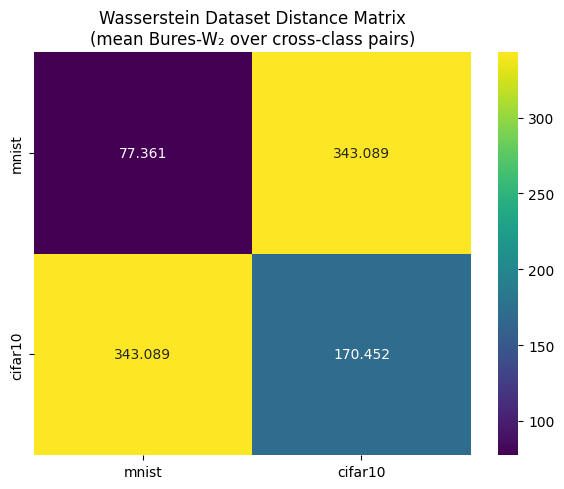

In [ ]:
class_offsets = [0]
for idx, dataset in enumerate(dataset_list):
    _, Y = embedder.preprocess_dataset(dataset, dataset_id=idx)
    num_classes = len(torch.unique(Y))
    class_offsets.append(class_offsets[-1] + num_classes)


n = len(dataset_names)
D_dataset = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        block = D[class_offsets[i]:class_offsets[i + 1],
                  class_offsets[j]:class_offsets[j + 1]]
        D_dataset[i, j] = block.mean().item()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(D_dataset, annot=True, fmt='.3f',
            xticklabels=dataset_names, yticklabels=dataset_names,
            cmap='viridis', ax=ax)
ax.set_title('Wasserstein Dataset Distance Matrix\n(mean Bures-W₂ over cross-class pairs)')
plt.tight_layout()
plt.show()

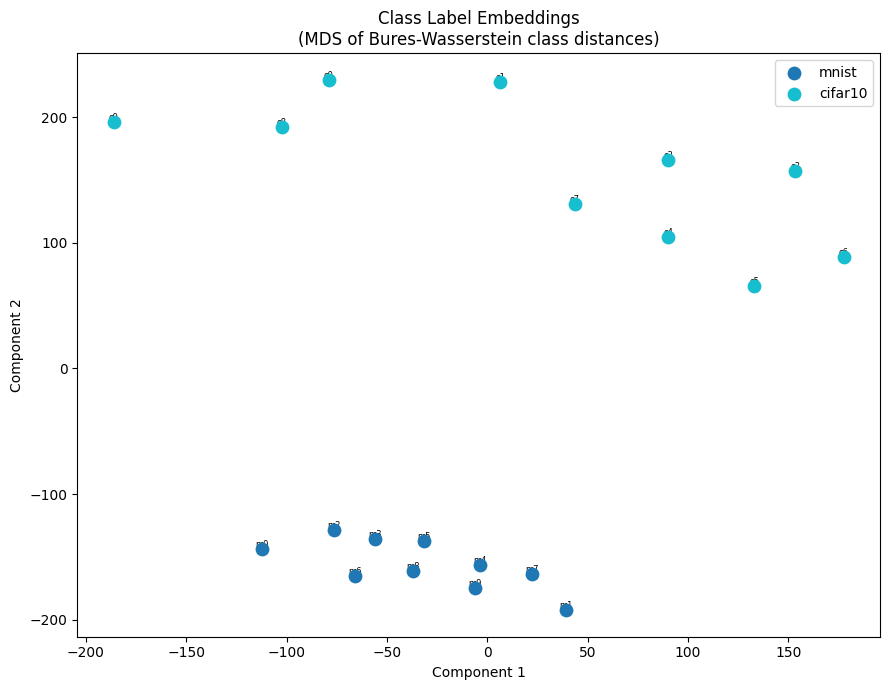

In [ ]:
label_embeddings = embedder.embed_distance_matrix(D, emb_dim=2)

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, n))

for i, (name, color) in enumerate(zip(dataset_names, colors)):
    start = class_offsets[i]
    end = class_offsets[i + 1]
    embs = label_embeddings[start:end].numpy()
    ax.scatter(embs[:, 0], embs[:, 1], color=color, s=80, label=name, zorder=5)
    for c in range(end - start):
        ax.annotate(f'{name[0]}{c}', (embs[c, 0], embs[c, 1]),
                    fontsize=6, ha='center', va='bottom')

ax.set_title('Class Label Embeddings\n(MDS of Bures-Wasserstein class distances)')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:


small_embedder = WassersteinEmbedder(
    emb_dim=2,
    device='cpu',
    max_samples=100,
    gaussian_assumption=True,
    diagonal_cov=True,
)

task_embeddings, label_embeddings_wte, augmented_datasets = small_embedder.compute_wte(
    dataset_list
)

print(f"Task embeddings:      {task_embeddings.shape}  [num_datasets, ref_size, feature_dim+emb_dim]")
print(f"Label embeddings:     {label_embeddings_wte.shape}  [total_classes, emb_dim]")
print(f"Augmented dataset 0:  {augmented_datasets[0].shape}  [num_samples, feature_dim+emb_dim]")

Preprocessing dataset:   0%|          | 0/2 [00:00<?, ?it/s]

Preprocessing dataset:   0%|          | 0/2 [00:00<?, ?it/s]

Preprocessing dataset: 100%|██████████| 2/2 [00:00<00:00, 19.28it/s]

Task embeddings:      torch.Size([2, 100, 150530])  [num_datasets, ref_size, feature_dim+emb_dim]
Label embeddings:     torch.Size([20, 2])  [total_classes, emb_dim]
Augmented dataset 0:  torch.Size([100, 150530])  [num_samples, feature_dim+emb_dim]
